# 02. Preprocessing & Baseline Modeling
**Objective:** Transform raw text into standardized features and establish a performance benchmark.

### Step 1: Environment Setup
We initialize the NLP toolkit and machine learning libraries.

In [1]:
import pandas as pd
import numpy as np
import re
import spacy
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from nltk.sentiment import SentimentIntensityAnalyzer

# Load spaCy and VADER
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
sia = SentimentIntensityAnalyzer()

### Step 2: Preprocessing Pipeline
We define a standardization function to lowercase text, remove noise, and apply **Lemmatization** to reduce words to their base forms.

In [2]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Remove URLs and special characters
    text = re.sub(r"http\S+|[^a-zA-Z\s]", "", text.lower())
    # Tokenize and Lemmatize while removing stop words
    doc = nlp(text)
    cleaned = [
        token.lemma_ for token in doc if not token.is_stop and len(token.text) > 2
    ]
    return " ".join(cleaned)


# Define Sentiment Labeling via VADER
def get_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"
    return "neutral"

### Step 3: Loading & Transforming Data
Applying the preprocessing and labeling functions to our datasets.

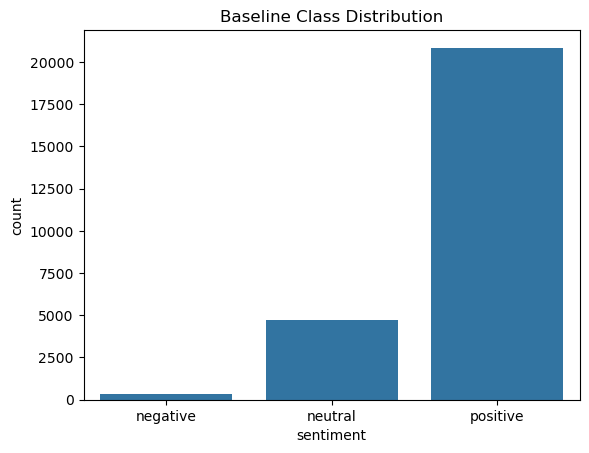

In [3]:
# Load processed EDA data
df = pd.read_csv("../data/processed/amazon_cleaned.csv")
df = pd.read_csv("../data/processed/mendeley_cleaned.csv")


# Apply transformations
df["clean_text"] = df["Review"].apply(clean_text)
df["sentiment"] = df["Review"].apply(get_sentiment)

# Visualize Imbalance
sns.countplot(x="sentiment", data=df, order=["negative", "neutral", "positive"])
plt.title("Baseline Class Distribution")
plt.show()

### Step 4: Baseline Training (TF-IDF + Naive Bayes)
We use the original imbalanced data to see how a simple model performs in real-world conditions.

In [4]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"],
)

# Build Pipeline
baseline_pipe = Pipeline(
    [("tfidf", TfidfVectorizer(max_features=5000)), ("nb", MultinomialNB())]
)

# Train and Predict
baseline_pipe.fit(X_train, y_train)
y_pred = baseline_pipe.predict(X_test)

# Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      0.05      0.09        65
     neutral       0.96      0.40      0.57       943
    positive       0.87      1.00      0.93      4168

    accuracy                           0.88      5176
   macro avg       0.94      0.48      0.53      5176
weighted avg       0.89      0.88      0.85      5176



### Step 5: Exporting Assets
Saving the model and vectorizer so Ainsley and Dennis can use them for Phase 03 and 04.

In [5]:
import os

os.makedirs("../models", exist_ok=True)

# Save the full pipeline
joblib.dump(baseline_pipe, "../models/baseline_model.pkl")

# Save the TF-IDF vectorizer separately for Ainsley
joblib.dump(baseline_pipe.named_steps["tfidf"], "../models/vectorizer.pkl")

print("Phase 02 Complete: Models saved to /models")

Phase 02 Complete: Models saved to /models
